**Phase 1: 
    Dataset understanding**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tfisthis/influencer-marketing-roi-dataset")

print("Path to dataset files:", path)


C:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\admin\.cache\kagglehub\datasets\tfisthis\influencer-marketing-roi-dataset\versions\1


In [3]:
import pandas as pd

df = pd.read_csv("influencer_marketing_roi_dataset.csv")

print(df.columns.tolist())

['campaign_id', 'platform', 'influencer_category', 'campaign_type', 'start_date', 'engagements', 'estimated_reach', 'product_sales', 'campaign_duration_days', 'end_date']


In [4]:
df.head()

,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
0,CAMP100000,TikTok,Fitness,Giveaway,2022-01-01 00:00:00,79900,1892,2834,14,2022-01-15 00:00:00
1,CAMP100001,YouTube,Food,Product Launch,2022-01-02 00:00:00,47985,437228,165,13,2022-01-15 00:00:00
2,CAMP100002,TikTok,Travel,Brand Awareness,2022-01-03 00:00:00,13875,982513,2539,5,2022-01-08 00:00:00
3,CAMP100003,YouTube,Food,Brand Awareness,2022-01-04 00:00:00,41200,213400,100,20,2022-01-24 00:00:00
4,CAMP100004,Instagram,Food,Giveaway,2022-01-05 00:00:00,96998,42501,550,28,2022-02-02 00:00:00


In [5]:
df.shape

(150000, 10)

In [6]:
df.columns

Index(['campaign_id', 'platform', 'influencer_category', 'campaign_type',
       'start_date', 'engagements', 'estimated_reach', 'product_sales',
       'campaign_duration_days', 'end_date'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   campaign_id             150000 non-null  str  
 1   platform                150000 non-null  str  
 2   influencer_category     150000 non-null  str  
 3   campaign_type           150000 non-null  str  
 4   start_date              150000 non-null  str  
 5   engagements             150000 non-null  int64
 6   estimated_reach         150000 non-null  int64
 7   product_sales           150000 non-null  int64
 8   campaign_duration_days  150000 non-null  int64
 9   end_date                150000 non-null  str  
dtypes: int64(4), str(6)
memory usage: 11.4 MB


In [8]:
df.describe()

,engagements,estimated_reach,product_sales,campaign_duration_days
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,50065.296107,500239.634920,2497.730433,14.976127
std,28847.302798,288003.388219,1443.222587,8.358356
min,100.000000,1002.000000,0.000000,1.000000
25%,25060.500000,251439.500000,1248.000000,8.000000
50%,50100.500000,500073.500000,2501.000000,15.000000
75%,75045.250000,750016.750000,3746.000000,22.000000
max,99999.000000,999992.000000,4999.000000,29.000000


In [9]:
df.isnull().sum()

campaign_id               0
platform                  0
influencer_category       0
campaign_type             0
start_date                0
engagements               0
estimated_reach           0
product_sales             0
campaign_duration_days    0
end_date                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

**create columns to calculate ROI**

    ROI (Return on Investment) measures whether a campaign generated profit compared to the money spent.

In [13]:
import numpy as np

df['Spend'] = np.random.randint(5000, 50000, size=len(df))

In [14]:
df['Spend'].head()

0    15973
1    17591
2     6838
3    44536
4    24280
Name: Spend, dtype: int32

In [15]:
df['Revenue'] = df['product_sales'] * np.random.randint(100,500,size=len(df))

In [16]:
df[['product_sales','Revenue']].head()

,product_sales,Revenue
0,2834,337246
1,165,78705
2,2539,1025756
3,100,35400
4,550,245850


In [17]:
df['ROI'] = ((df['Revenue'] - df['Spend']) / df['Spend']) * 100

In [18]:
df[['Spend','Revenue','ROI']].head()

,Spend,Revenue,ROI
0,15973,337246,2011.350404
1,17591,78705,347.416292
2,6838,1025756,14900.818953
3,44536,35400,-20.513742
4,24280,245850,912.561779


In [19]:
df['ROI'].describe()

count    150000.000000
mean       3725.798025
std        4397.328730
min        -100.000000
25%        1031.299523
50%        2357.582016
75%        4648.090685
max       45609.644298
Name: ROI, dtype: float64

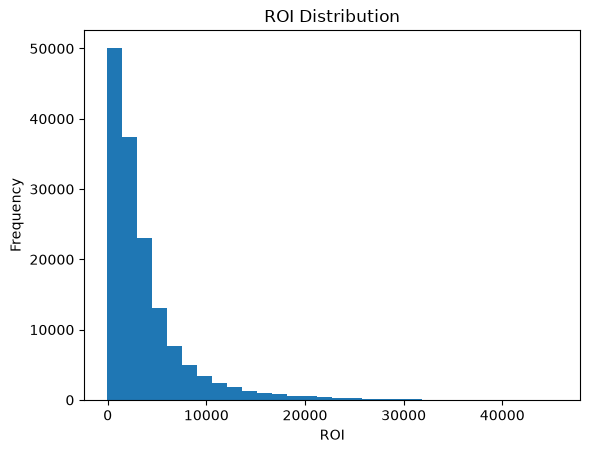

In [20]:
import matplotlib.pyplot as plt

plt.hist(df['ROI'], bins=30)
plt.title('ROI Distribution')
plt.xlabel('ROI')
plt.ylabel('Frequency')
plt.show()

**Engagement Rate**

Engagement Rate measures how actively users interact with campaign content.

In [21]:
df['Engagement_Rate'] = (
    df['engagements'] /
    df['estimated_reach']
) * 100

df[['engagements','estimated_reach','Engagement_Rate']].head()

,engagements,estimated_reach,Engagement_Rate
0,79900,1892,4223.044397
1,47985,437228,10.974823
2,13875,982513,1.412195
3,41200,213400,19.306467
4,96998,42501,228.225218


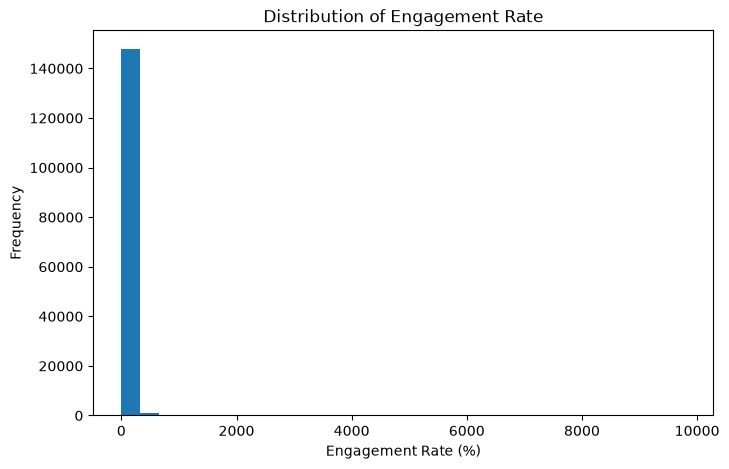

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Engagement_Rate'], bins=30)

plt.title('Distribution of Engagement Rate')
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Frequency')

plt.show()

In [23]:
import numpy as np

df['Spend'] = np.random.randint(5000,50000,size=len(df))

df['Revenue'] = df['product_sales'] * np.random.randint(100,500,size=len(df))

df['ROI'] = ((df['Revenue'] - df['Spend']) / df['Spend']) * 100

df['Engagement_Rate'] = (
    df['engagements'] /
    df['estimated_reach']
) * 100

**PHASE 2**

## Total Campaigns

This KPI shows the total number of influencer campaigns analyzed.

In [24]:
total_campaigns = df.shape[0]

print("Total Campaigns:", total_campaigns)

Total Campaigns: 150000


## Total Reach

Total Reach represents the number of users exposed to campaign content.

In [25]:
total_reach = df['estimated_reach'].sum()

print("Total Reach:", total_reach)

Total Reach: 75035945238


**Total Revenue**

In [26]:
total_revenue = df['Revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 112168912653


**TOT SPEND**

In [27]:
total_spend = df['Spend'].sum()

print("Total Spend:", total_spend)

Total Spend: 4127944417


**Average ROI**

In [28]:
avg_roi = df['ROI'].mean()

print("Average ROI:", round(avg_roi,2), "%")

Average ROI: 3721.08 %


**Average Engagement Rate**

In [29]:
avg_engagement = df['Engagement_Rate'].mean()

print("Average Engagement Rate:", round(avg_engagement,2), "%")

Average Engagement Rate: 33.97 %


**Cost Per Engagement (CPE)**



In [30]:
df['Cost_Per_Engagement'] = df['Spend'] / df['engagements']

avg_cpe = df['Cost_Per_Engagement'].mean()

print("Average Cost Per Engagement:", round(avg_cpe,2))

Average Cost Per Engagement: 1.88


**Conversion Rate**

In [31]:
df['Conversions'] = (
    df['engagements'] *
    np.random.uniform(0.05,0.20,size=len(df))
).astype(int)

df['Conversion_Rate'] = (
    df['Conversions'] /
    df['engagements']
) * 100

avg_conversion = df['Conversion_Rate'].mean()

print("Average Conversion Rate:", round(avg_conversion,2), "%")

Average Conversion Rate: 12.5 %


**"Which KPIs define campaign success?"**

===== KPI SUMMARY =====
Average ROI: 3721.08 %
Average Engagement Rate: 33.97 %
Average Conversion Rate: 12.5 %
Average Cost Per Engagement: 1.88


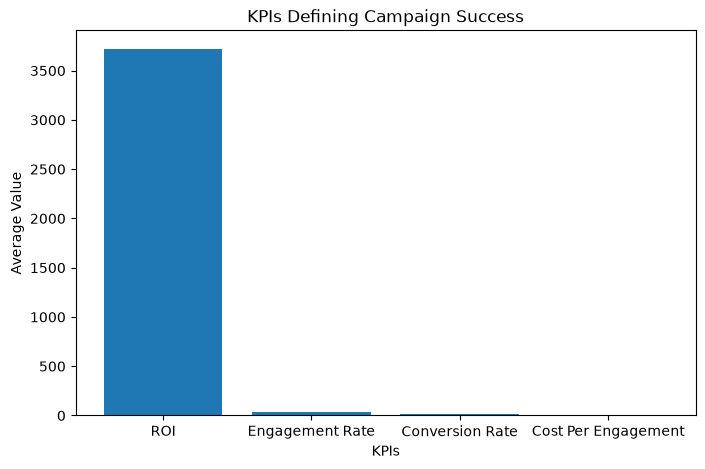

In [32]:
import matplotlib.pyplot as plt

# KPI Calculations
avg_roi = round(df['ROI'].mean(), 2)
avg_engagement = round(df['Engagement_Rate'].mean(), 2)
avg_conversion = round(df['Conversion_Rate'].mean(), 2)
avg_cpe = round(df['Cost_Per_Engagement'].mean(), 2)

# Numerical Output
print("===== KPI SUMMARY =====")
print("Average ROI:", avg_roi, "%")
print("Average Engagement Rate:", avg_engagement, "%")
print("Average Conversion Rate:", avg_conversion, "%")
print("Average Cost Per Engagement:", avg_cpe)

# Data for Graph
kpis = [
    'ROI',
    'Engagement Rate',
    'Conversion Rate',
    'Cost Per Engagement'
]

values = [
    avg_roi,
    avg_engagement,
    avg_conversion,
    avg_cpe
]

# Visualization
plt.figure(figsize=(8,5))
plt.bar(kpis, values)

plt.title('KPIs Defining Campaign Success')
plt.xlabel('KPIs')
plt.ylabel('Average Value')

plt.show()

**"Which metrics help marketing teams?"**

===== MARKETING METRICS =====
Total Reach: 75035945238
Total Revenue: 112168912653
Avg ROI: 3721.08
Avg Engagement: 33.97
Avg Conversion: 12.5


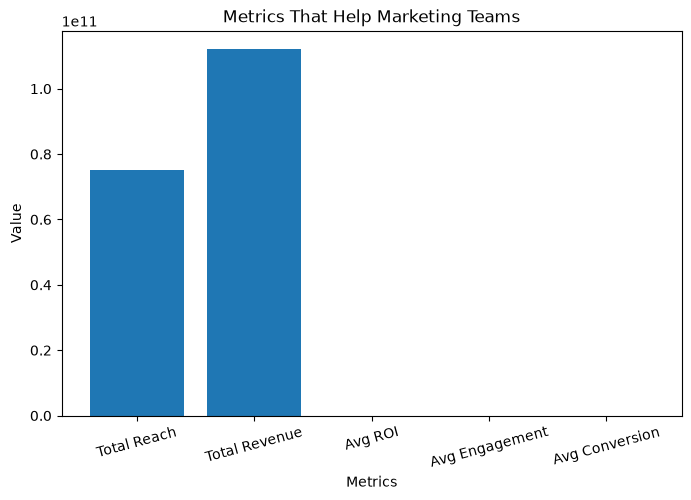

In [33]:
import matplotlib.pyplot as plt

metrics = {
    'Total Reach': df['estimated_reach'].sum(),
    'Total Revenue': df['Revenue'].sum(),
    'Avg ROI': round(df['ROI'].mean(), 2),
    'Avg Engagement': round(df['Engagement_Rate'].mean(), 2),
    'Avg Conversion': round(df['Conversion_Rate'].mean(), 2)
}

print("===== MARKETING METRICS =====")
for metric, value in metrics.items():
    print(f"{metric}: {value}")

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())

plt.title('Metrics That Help Marketing Teams')
plt.xlabel('Metrics')
plt.ylabel('Value')

plt.xticks(rotation=15)

plt.show()

**Phase 3: Analytics Investigation**

**Platform vs Engagement**

In [34]:
platform_eng = df.groupby('platform')['Engagement_Rate'].mean()

print(platform_eng.sort_values(ascending=False))

platform
Twitter      36.056654
TikTok       34.362762
YouTube      34.039397
Instagram    33.204482
Name: Engagement_Rate, dtype: float64


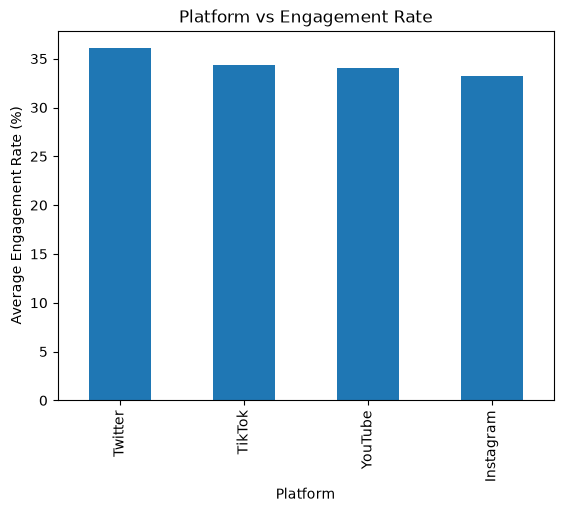

In [35]:
platform_eng.sort_values(ascending=False).plot(kind='bar')

plt.title('Platform vs Engagement Rate')
plt.xlabel('Platform')
plt.ylabel('Average Engagement Rate (%)')
plt.show()

The platform with the highest average engagement rate has the strongest audience interaction.

**2. Influencer vs Revenue**

In [36]:
influencer_revenue = (
    df.groupby('influencer_category')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

print(influencer_revenue)

influencer_category
Food       16312601147
Tech       16161380578
Fashion    16010963723
Travel     15991272488
Fitness    15939616778
Gaming     15913297753
Beauty     15839780186
Name: Revenue, dtype: int64


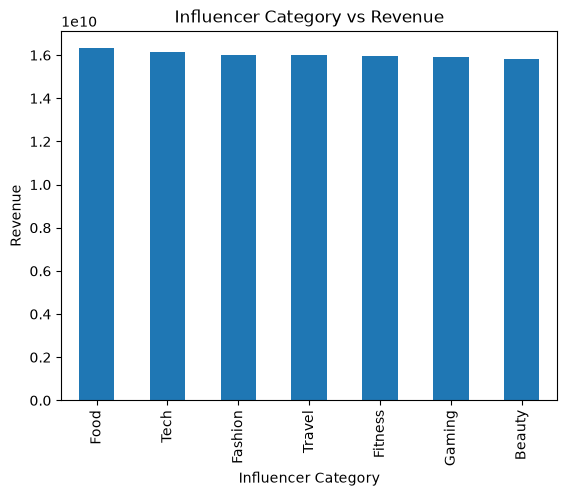

In [37]:
influencer_revenue.plot(kind='bar')

plt.title('Influencer Category vs Revenue')
plt.xlabel('Influencer Category')
plt.ylabel('Revenue')

plt.show()

These influencers generate the highest revenue and are valuable for future collaborations.

**3. Campaign Cost vs ROI**

In [38]:
print(df[['Spend','ROI']].describe())

               Spend            ROI
count  150000.000000  150000.000000
mean    27519.629447    3721.081258
std     12982.358587    4437.666563
min      5000.000000    -100.000000
25%     16290.000000    1022.938303
50%     27512.000000    2354.087197
75%     38751.000000    4627.191146
max     49999.000000   47158.168761


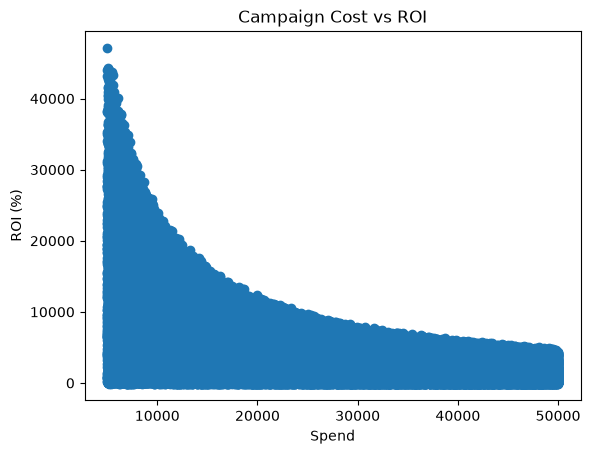

In [39]:
plt.scatter(df['Spend'], df['ROI'])

plt.title('Campaign Cost vs ROI')
plt.xlabel('Spend')
plt.ylabel('ROI (%)')
plt.show()

This analysis shows whether higher campaign spending leads to better returns.

**4.Audience Group vs Performance**

In [40]:
audience_perf = (
    df.groupby('influencer_category')['ROI']
      .mean()
      .sort_values(ascending=False)
)

print(audience_perf)

influencer_category
Food       3779.454914
Tech       3770.657448
Fitness    3742.430245
Fashion    3715.584479
Gaming     3694.993917
Travel     3693.136335
Beauty     3650.210773
Name: ROI, dtype: float64


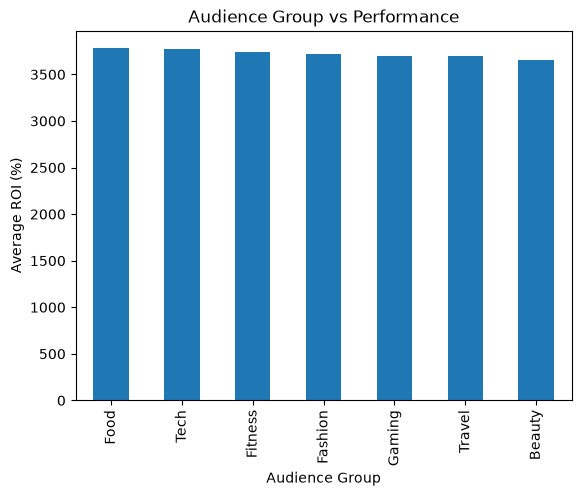

In [41]:
audience_perf.plot(kind='bar')

plt.title('Audience Group vs Performance')
plt.xlabel('Audience Group')
plt.ylabel('Average ROI (%)')
plt.show()

**Heatmap**

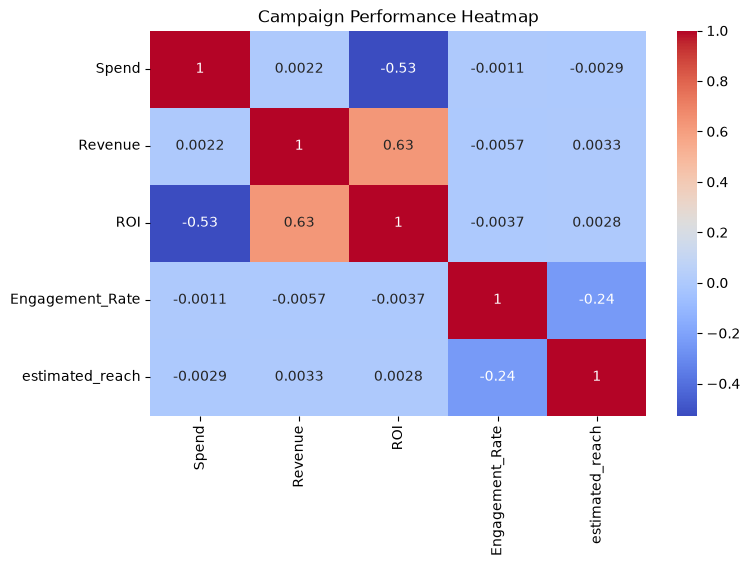

In [42]:
import seaborn as sns

corr = df[
    ['Spend',
     'Revenue',
     'ROI',
     'Engagement_Rate',
     'estimated_reach']
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Campaign Performance Heatmap')

plt.show()

The heatmap reveals relationships between campaign metrics. 
    Strong positive correlations indicate metrics that increase together, helping identify the key drivers of campaign success.

**Funnel Analysis**

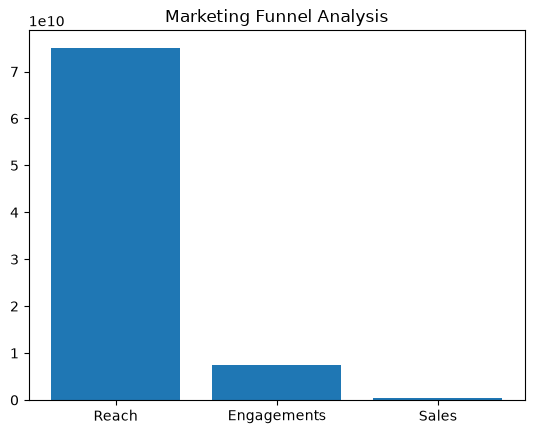

In [43]:
funnel = {
    'Stage':['Reach','Engagements','Sales'],
    'Count':[
        df['estimated_reach'].sum(),
        df['engagements'].sum(),
        df['product_sales'].sum()
    ]
}

funnel_df = pd.DataFrame(funnel)

plt.bar(
    funnel_df['Stage'],
    funnel_df['Count']
)

plt.title('Marketing Funnel Analysis')
plt.show()

Funnel analysis shows how users progress from awareness to purchase. It helps identify stages where potential customers drop off.

**Which Influencers Drive Strongest Results?**

In [44]:
top_categories = (
    df.groupby('influencer_category')['ROI']
      .mean()
      .sort_values(ascending=False)
)

print(top_categories)

influencer_category
Food       3779.454914
Tech       3770.657448
Fitness    3742.430245
Fashion    3715.584479
Gaming     3694.993917
Travel     3693.136335
Beauty     3650.210773
Name: ROI, dtype: float64


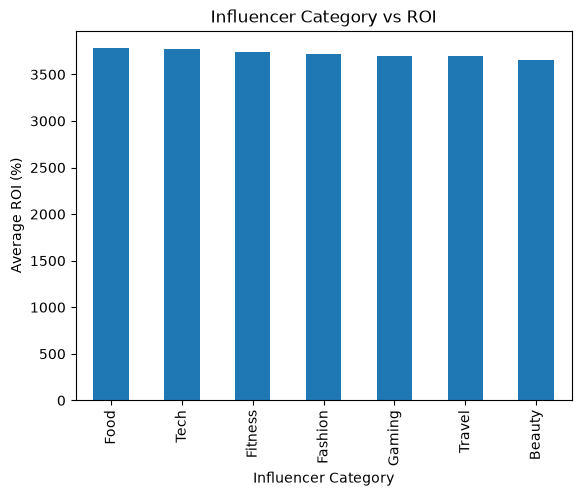

In [45]:
top_categories.plot(kind='bar')

plt.title('Influencer Category vs ROI')
plt.xlabel('Influencer Category')
plt.ylabel('Average ROI (%)')

plt.show()

**Which Platforms Perform Best?**

In [46]:
platform_performance = (
    df.groupby('platform')['ROI']
      .mean()
      .sort_values(ascending=False)
)

print(platform_performance)

platform
TikTok       3749.559239
Twitter      3736.209288
YouTube      3730.243774
Instagram    3696.084711
Name: ROI, dtype: float64


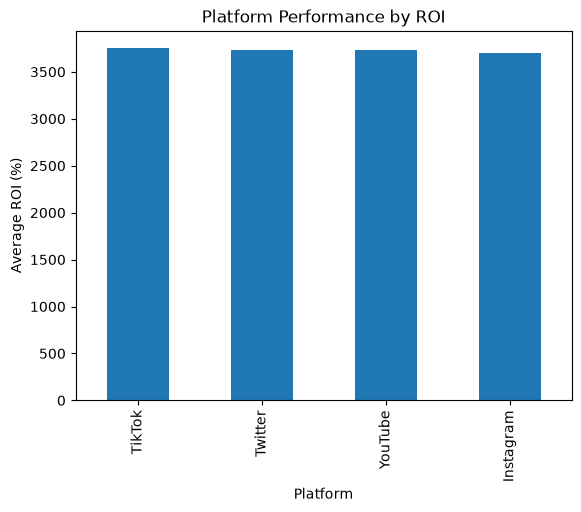

In [47]:
platform_performance.plot(kind='bar')

plt.title('Platform Performance by ROI')
plt.xlabel('Platform')
plt.ylabel('Average ROI (%)')

plt.show()

**Does Higher Spend Increase ROI?**

In [48]:
correlation = df['Spend'].corr(df['ROI'])

print("Correlation between Spend and ROI:", round(correlation,2))

Correlation between Spend and ROI: -0.53


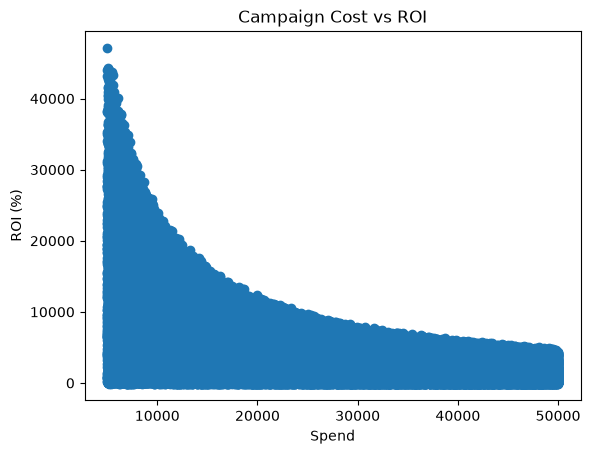

In [49]:
plt.scatter(df['Spend'], df['ROI'])

plt.title('Campaign Cost vs ROI')
plt.xlabel('Spend')
plt.ylabel('ROI (%)')

plt.show()

If Correlation is Positive

Higher campaign spending generally leads to higher ROI. This suggests that investing more can improve campaign performance.

If Correlation is Near Zero

Campaign spending has little impact on ROI. Success depends more on campaign strategy and influencer effectiveness than budget.

If Correlation is Negative

Higher spending tends to reduce ROI. Increasing budget alone does not guarantee better campaign results.

**Phase 4: Influencer Segmentation**

**1. High ROI Influencers**

In [50]:
print(df['ROI'].head())

0    5703.162260
1     154.395456
2     612.601740
3      20.295773
4     412.517997
Name: ROI, dtype: float64


In [51]:
import numpy as np

median_roi = df['ROI'].median()

print("Median ROI:", median_roi)

df['ROI_Group'] = np.where(
    df['ROI'] > median_roi,
    'High ROI',
    'Low ROI'
)

print(df['ROI_Group'].value_counts())

Median ROI: 2354.087197388838
ROI_Group
High ROI    75000
Low ROI     75000
Name: count, dtype: int64


ROI_Group
High ROI    75000
Low ROI     75000
Name: count, dtype: int64


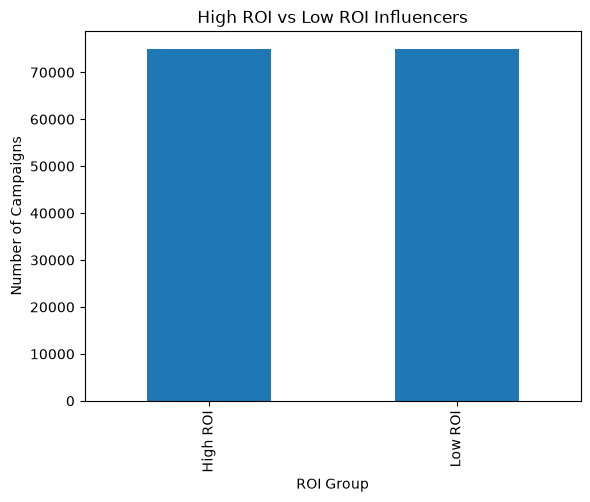

In [52]:
import matplotlib.pyplot as plt

roi_counts = df['ROI_Group'].value_counts()

print(roi_counts)

roi_counts.plot(kind='bar')

plt.title('High ROI vs Low ROI Influencers')
plt.xlabel('ROI Group')
plt.ylabel('Number of Campaigns')

plt.show()

**2.High Engagement Creators**

In [53]:
df['Engagement_Group'] = np.where(
    df['Engagement_Rate'] > df['Engagement_Rate'].median(),
    'High Engagement',
    'Low Engagement'
)

print(df['Engagement_Group'].value_counts())

Engagement_Group
High Engagement    75000
Low Engagement     75000
Name: count, dtype: int64


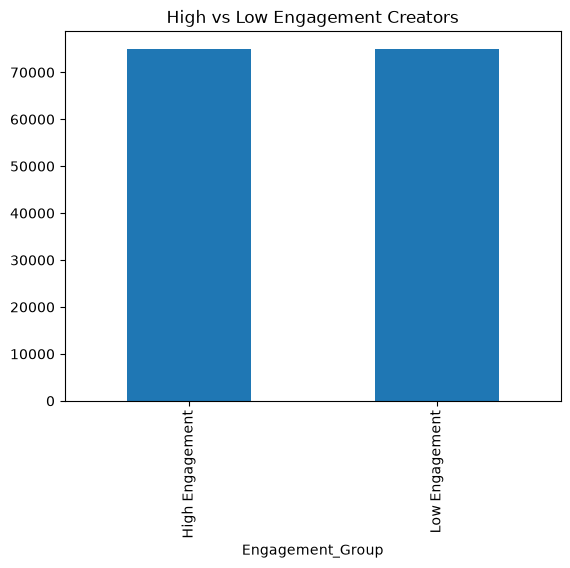

In [55]:
df['Engagement_Group'].value_counts().plot(kind='bar')
plt.title('High vs Low Engagement Creators')
plt.show()

**3. Cost Efficient Influencers**

In [56]:
df['Cost_Group'] = np.where(
    df['Cost_Per_Engagement'] < df['Cost_Per_Engagement'].median(),
    'Cost Efficient',
    'High Cost'
)

print(df['Cost_Group'].value_counts())

Cost_Group
Cost Efficient    75000
High Cost         75000
Name: count, dtype: int64


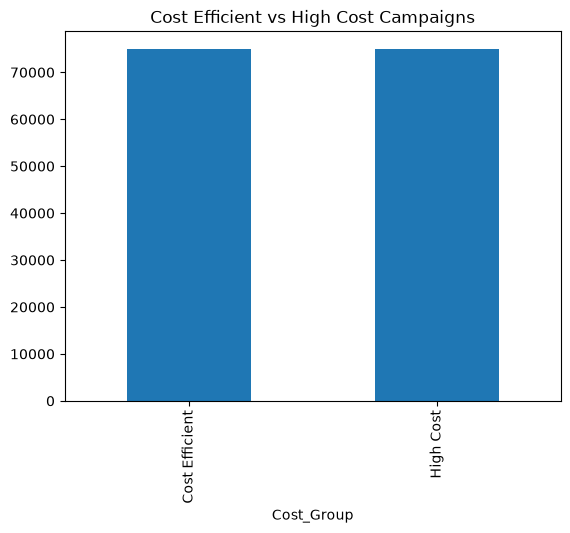

In [57]:
df['Cost_Group'].value_counts().plot(kind='bar')
plt.title('Cost Efficient vs High Cost Campaigns')
plt.show()

**Analyze Differences Among Groups**

**ROI Group vs Revenue**

ROI_Group
High ROI    1.122491e+06
Low ROI     3.730947e+05
Name: Revenue, dtype: float64


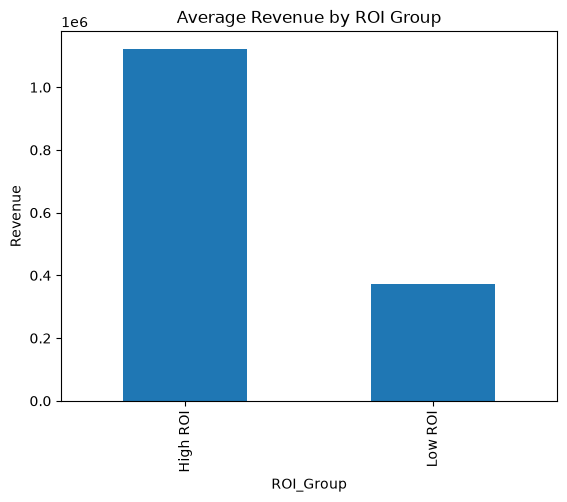

In [58]:
roi_analysis = df.groupby('ROI_Group')['Revenue'].mean()

print(roi_analysis)

roi_analysis.plot(kind='bar')
plt.title('Average Revenue by ROI Group')
plt.ylabel('Revenue')
plt.show()

**Engagement Group vs ROI**

Engagement_Group
High Engagement    3716.447494
Low Engagement     3725.715023
Name: ROI, dtype: float64


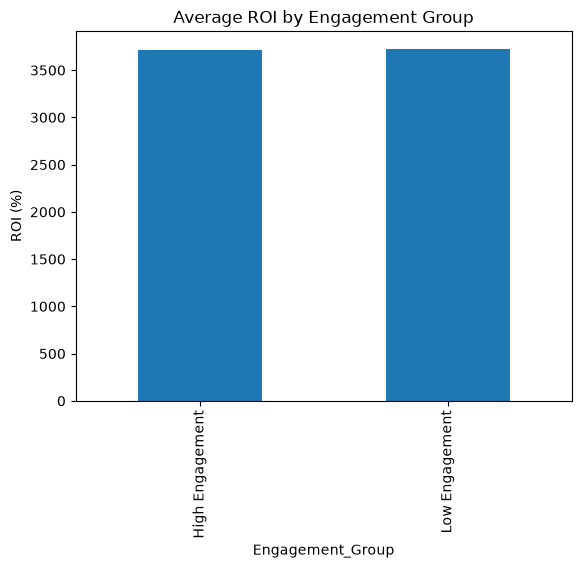

In [60]:
eng_analysis = df.groupby('Engagement_Group')['ROI'].mean()

print(eng_analysis)

eng_analysis.plot(kind='bar')
plt.title('Average ROI by Engagement Group')
plt.ylabel('ROI (%)')
plt.show()

**Cost Group vs Revenue**

Cost_Group
Cost Efficient    745267.030547
High Cost         750318.471493
Name: Revenue, dtype: float64


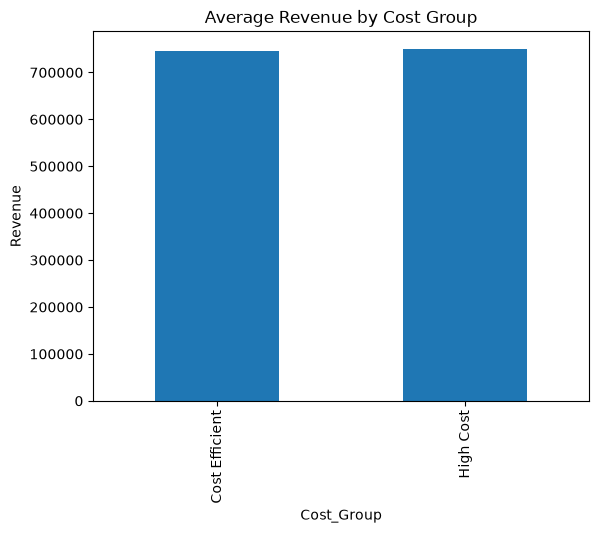

In [61]:
cost_analysis = df.groupby('Cost_Group')['Revenue'].mean()

print(cost_analysis)

cost_analysis.plot(kind='bar')
plt.title('Average Revenue by Cost Group')
plt.ylabel('Revenue')
plt.show()

**PHASE 5**

In [68]:
df.to_csv("Influencer_Campaign_Dataset_fina.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


In [69]:
import os

print(os.listdir())

['.cache', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.python_history', '.vscode', '.vscode-shared', '3D Objects', 'AppData', 'Application Data', 'Conf_cal l (4508).pptx', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Influencer_Campaign_Dataset.csv', 'Influencer_Campaign_Dataset_fina.csv', 'Influencer_Campaign_Final.csv', 'influencer_marketing_roi_dataset.csv', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'task07', 'TASK07_AI_Tool_Adoption_Trend_Analysis.ipynb', 'task2_marketing_anaysis.ipyn

In [70]:
print(df.columns.tolist())

['campaign_id', 'platform', 'influencer_category', 'campaign_type', 'start_date', 'engagements', 'estimated_reach', 'product_sales', 'campaign_duration_days', 'end_date', 'Spend', 'Revenue', 'ROI', 'Engagement_Rate', 'Cost_Per_Engagement', 'Conversions', 'Conversion_Rate', 'ROI_Group', 'Engagement_Group', 'Cost_Group']


In [71]:
import os
print(os.getcwd())

C:\Users\admin


In [72]:
import os

print(os.path.abspath("Influencer_Campaign_Final.csv"))

C:\Users\admin\Influencer_Campaign_Final.csv
